# TEMA (3EMA) + MACD Binary Ensemble — BTC & SOL

**Philosophy, deliberately different from the main unified-engine notebook:** "Toyota, not
Ferrari." Two trend indicators, fixed periods, no per-asset optimization, a binary in/out
state instead of a continuous forecast, and a "boundless" exit — no fixed stop-loss or take
profit, the position closes only when the ensemble itself flips. Fewer parameters means fewer
ways to overfit, at the cost of giving up some of the nuance the bigger engine has.

**How the ensemble votes:**
- **3EMA/TEMA leg:** three EMAs (fast/mid/slow). Bullish alignment (fast > mid > slow) votes
  up; bearish alignment votes down; anything else is a "no vote."
- **MACD leg:** standard MACD line vs. signal line, votes up/down the same way.
- **Combine:** the position only **flips** when both legs agree in the same direction. If they
  disagree, or either is in a "no vote" state, the **previous position holds** — this is the
  "boundless" part: no predefined exit level, the position rides until the ensemble itself
  changes its mind.

**Long-only by default**, consistent with everything else built in this conversation for
prop-account suitability — bearish agreement flattens the position rather than shorting.

## 0 — Config

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

ANN_DAYS   = 365     # crypto trades every calendar day
COST_BPS   = 10.0    # wider than the equity engine's 5bps -- crypto spreads are typically wider
VOL_TARGET = 0.25     # crypto sized to a higher vol target than the equity book, still capped

TEMA_PERIODS = (20, 50, 100)              # fast / mid / slow EMA alignment -- fixed, not optimized
MACD_FAST, MACD_SLOW, MACD_SIGNAL = 12, 26, 9   # the standard convention, unchanged

TICKERS = ["BTC-USD", "SOL-USD"]


## 1 — Data layer

Same pattern as the main notebook: tries real data via `yfinance` first, falls back to a
synthetic crypto panel (shared regime process, correlated but not identical between BTC/SOL)
so this runs offline. Same sandbox network caveat applies — see the main notebook's Section 1
for the full explanation and how to run this with real data.

In [2]:
def synthetic_crypto(names, n_days=1500, seed=3, s0=100.0):
    rng = np.random.default_rng(seed)
    idx = pd.date_range(end=pd.Timestamp.today().normalize(), periods=n_days, freq="D")
    P = np.array([[0.97, 0.01, 0.02], [0.02, 0.96, 0.02], [0.02, 0.02, 0.96]])
    mu = np.array([0.0012, -0.0015, 0.0003]); bvol = np.array([0.025, 0.045, 0.020])
    st, hm, mkt = 0, 0.0, []
    for _ in range(n_days):
        st = rng.choice(3, p=P[st]); hm = 0.94 * hm + 0.06 * rng.normal()
        mkt.append(mu[st] + bvol[st] * np.exp(0.5 * hm) * rng.normal())
    mkt = np.array(mkt)
    cols = {}
    for name in names:
        b = rng.uniform(0.8, 1.6); iv = rng.uniform(0.015, 0.030)
        idio_hm, idio = 0.0, []
        for _ in range(n_days):
            idio_hm = 0.96 * idio_hm + 0.04 * rng.normal()
            idio.append(iv * np.exp(0.5 * idio_hm) * rng.normal())
        r = b * mkt + np.array(idio)
        cols[name] = s0 * np.exp(np.cumsum(r))
    return pd.DataFrame(cols, index=idx)


def load_crypto(tickers, use_yfinance=True, start="2018-01-01"):
    if use_yfinance:
        try:
            import yfinance as yf
            data = yf.download(tickers, start=start, progress=False, auto_adjust=True)["Close"]
            if isinstance(data, pd.Series):
                data = data.to_frame(tickers[0])
            data = data.dropna(how="all").ffill().dropna()
            if len(data) > 100:
                print("[data] Loaded real crypto data from yfinance.")
                return data
        except Exception as e:
            print(f"[data] yfinance unavailable ({type(e).__name__}: {e}); using synthetic fallback.")
    return synthetic_crypto(tickers)


panel = load_crypto(TICKERS)
print(f"Universe: {list(panel.columns)}  |  bars: {len(panel)}  |  "
      f"{panel.index[0].date()} -> {panel.index[-1].date()}")
panel.tail()


Failed to get ticker 'SOL-USD' reason: Expecting value: line 1 column 1 (char 0)


HTTP Error 403: Host not in allowlist: query2.finance.yahoo.com. Add this host to your network egress settings to allow access.


HTTP Error 403: Host not in allowlist: query1.finance.yahoo.com. Add this host to your network egress settings to allow access.


Failed to get ticker 'BTC-USD' reason: Expecting value: line 1 column 1 (char 0)


HTTP Error 403: Host not in allowlist: query2.finance.yahoo.com. Add this host to your network egress settings to allow access.


HTTP Error 403: Host not in allowlist: query1.finance.yahoo.com. Add this host to your network egress settings to allow access.



2 Failed downloads:


['SOL-USD', 'BTC-USD']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')


Universe: ['BTC-USD', 'SOL-USD']  |  bars: 1500  |  2022-08-04 -> 2026-09-11


,BTC-USD,SOL-USD
2026-09-07,65.967690,227.829666
2026-09-08,69.346966,239.057825
2026-09-09,73.807276,252.426561
2026-09-10,72.123240,256.845092
2026-09-11,77.557742,278.023259


## 2 — The two voting legs

In [3]:
def tema_vote(close, periods=TEMA_PERIODS):
    """3EMA alignment vote: +1 bullish stack, -1 bearish stack, 0 = no clean alignment."""
    fast, mid, slow = periods
    ema_f = close.ewm(span=fast, adjust=False).mean()
    ema_m = close.ewm(span=mid, adjust=False).mean()
    ema_s = close.ewm(span=slow, adjust=False).mean()
    vote = pd.Series(0, index=close.index)
    vote[(ema_f > ema_m) & (ema_m > ema_s)] = 1
    vote[(ema_f < ema_m) & (ema_m < ema_s)] = -1
    return vote


def macd_vote(close, fast=MACD_FAST, slow=MACD_SLOW, signal=MACD_SIGNAL):
    """Standard MACD vote: +1 line above signal, -1 line below signal."""
    macd_line = close.ewm(span=fast, adjust=False).mean() - close.ewm(span=slow, adjust=False).mean()
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    vote = pd.Series(0, index=close.index)
    vote[macd_line > signal_line] = 1
    vote[macd_line < signal_line] = -1
    return vote


## 3 — Ensemble: binary queue with a boundless exit

The position only changes when **both legs agree**. Disagreement or a "no vote" from either
leg means the current position simply holds — there's no predefined exit level, no ATR stop,
no fixed take-profit. The trend indicators themselves are the only exit mechanism.

In [4]:
def ensemble_state(close, tema_periods=TEMA_PERIODS,
                    macd_params=(MACD_FAST, MACD_SLOW, MACD_SIGNAL), long_short=False):
    v_tema = tema_vote(close, tema_periods)
    v_macd = macd_vote(close, *macd_params)

    state = np.zeros(len(close), dtype=int)
    current = 0
    for i in range(len(close)):
        if v_tema.iloc[i] == 1 and v_macd.iloc[i] == 1:
            current = 1
        elif v_tema.iloc[i] == -1 and v_macd.iloc[i] == -1:
            current = -1 if long_short else 0    # long-only default: bearish agreement -> flat
        # else: legs disagree or one is neutral -> HOLD current state (the "boundless" part)
        state[i] = current
    return pd.Series(state, index=close.index), v_tema, v_macd


## 4 — Vol-targeted sizing + cost-aware backtest

In [5]:
def ewm_std(x, span):
    a = 2.0 / (span + 1.0)
    m = x.ewm(alpha=a, adjust=False).mean()
    m2 = (x * x).ewm(alpha=a, adjust=False).mean()
    var = (m2 - m * m).clip(lower=0.0)
    bc = (2.0 - 2.0 * a) / (2.0 - a)
    return np.sqrt(var / bc)


def vol_target_size(close, state, vol_target=VOL_TARGET, ann_days=ANN_DAYS, max_leverage=2.0):
    ret = close.pct_change().fillna(0.0)
    vol = (ewm_std(ret, 30) * np.sqrt(ann_days)).clip(lower=0.05)
    size = (vol_target / vol).clip(upper=max_leverage)
    return state * size


def backtest(close, position, cost_bps=COST_BPS):
    ret = close.pct_change().fillna(0.0)
    pos = position.shift(1).fillna(0.0)         # trade on next bar -- no lookahead
    turnover = pos.diff().abs().fillna(pos.abs())
    costs = turnover * (cost_bps / 1e4)
    strat_ret = pos * ret - costs
    equity = (1.0 + strat_ret).cumprod()
    return pd.DataFrame({"ret": strat_ret, "equity": equity, "position": pos, "turnover": turnover})


def annualized_sharpe(r, ann_days=ANN_DAYS):
    mu, sd = r.mean(), r.std()
    return float(np.sqrt(ann_days) * mu / sd) if sd > 0 else 0.0


def max_drawdown(equity):
    return float((equity / equity.cummax() - 1.0).min())


def report(name, bt, ann_days=ANN_DAYS):
    sr = annualized_sharpe(bt["ret"], ann_days)
    mdd = max_drawdown(bt["equity"])
    tot = bt["equity"].iloc[-1] - 1
    print(f"{name:12s} | Sharpe {sr:6.2f} | TotRet {tot:8.1%} | MaxDD {mdd:7.1%} | "
          f"AvgTurnover/yr {bt['turnover'].mean()*ann_days:5.1f}")
    return {"sharpe": sr, "total_return": tot, "max_dd": mdd}


## 5 — Run it: BTC and SOL, ensemble vs. buy & hold

--- BTC-USD ---
Ensemble     | Sharpe   0.27 | TotRet    13.9% | MaxDD  -20.3% | AvgTurnover/yr   3.0
Buy&Hold     | Sharpe   0.36 | TotRet   -21.6% | MaxDD  -78.0% | AvgTurnover/yr   0.2
  State flips over the backtest: 14  |  Time spent long: 45%



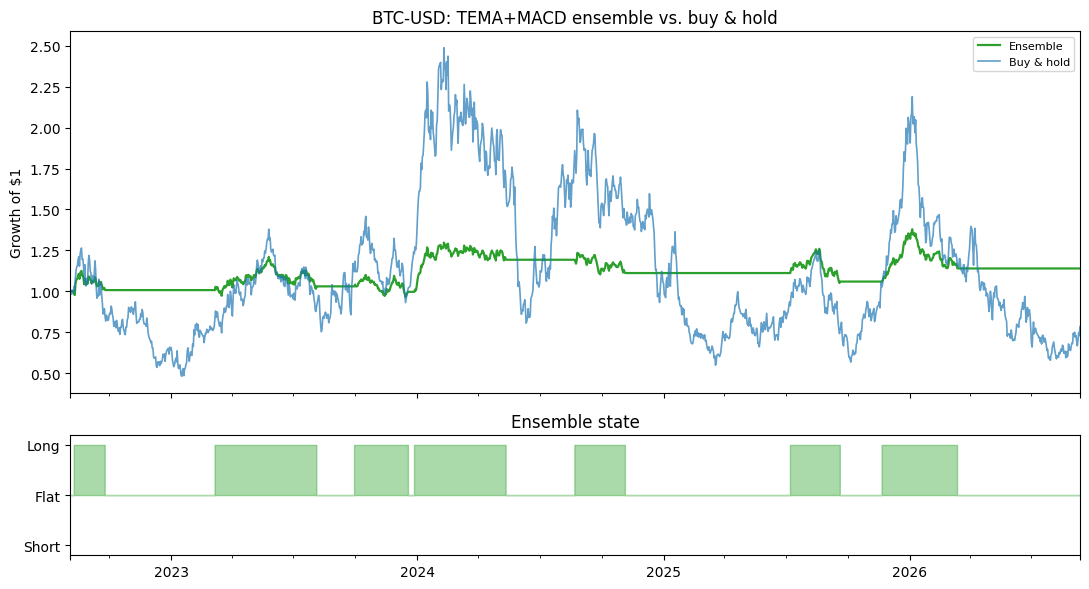

--- SOL-USD ---
Ensemble     | Sharpe   0.54 | TotRet    46.8% | MaxDD  -45.3% | AvgTurnover/yr   4.1
Buy&Hold     | Sharpe   0.71 | TotRet   181.1% | MaxDD  -89.2% | AvgTurnover/yr   0.2
  State flips over the backtest: 13  |  Time spent long: 62%



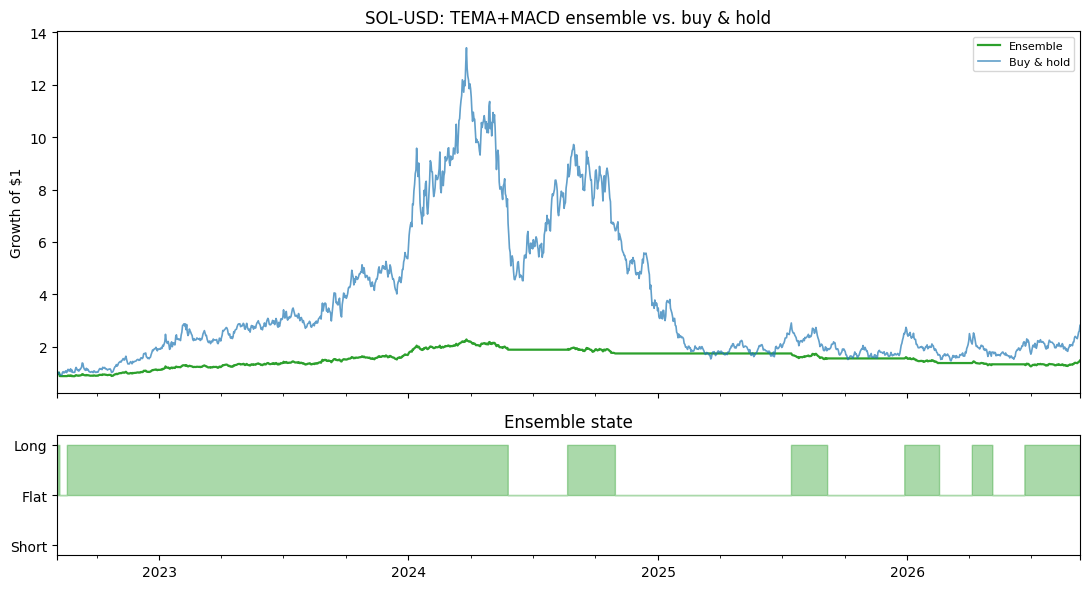

In [6]:
results = {}
for tkr in TICKERS:
    close = panel[tkr].dropna()
    state, v_tema, v_macd = ensemble_state(close)
    position = vol_target_size(close, state)
    bt = backtest(close, position)
    bh = backtest(close, pd.Series(1.0, index=close.index))

    print(f"--- {tkr} ---")
    results[tkr] = {"ensemble": report("Ensemble", bt), "buy_hold": report("Buy&Hold", bh)}
    n_flips = int((state.diff().fillna(0) != 0).sum())
    pct_long = float((state == 1).mean())
    print(f"  State flips over the backtest: {n_flips}  |  Time spent long: {pct_long:.0%}\n")

    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
    bt["equity"].plot(ax=axes[0], label="Ensemble", lw=1.6, color="tab:green")
    bh["equity"].plot(ax=axes[0], label="Buy & hold", lw=1.2, alpha=0.7, color="tab:blue")
    axes[0].set_title(f"{tkr}: TEMA+MACD ensemble vs. buy & hold"); axes[0].legend(fontsize=8)
    axes[0].set_ylabel("Growth of $1")

    axes[1].fill_between(state.index, 0, state.values, step="mid", color="tab:green", alpha=0.4)
    axes[1].set_ylim(-1.2, 1.2); axes[1].set_yticks([-1, 0, 1]); axes[1].set_yticklabels(["Short", "Flat", "Long"])
    axes[1].set_title("Ensemble state")
    plt.tight_layout(); plt.show()


## 6 — Parameter-stability sweep

Same philosophy as the main notebook's Section 6c: perturb the fixed periods and confirm the
result doesn't collapse. This is a robustness **check**, never an optimization loop — adopting
whichever perturbation happens to score best here would just reintroduce the overfitting this
whole "fixed parameters" approach exists to avoid.

--- BTC-USD stability sweep ---
   tema_period_scale    sharpe    max_dd
0               0.70  0.354218 -0.206565
1               0.85  0.330796 -0.201812
2               1.00  0.267586 -0.202599
3               1.15  0.265327 -0.228246
4               1.30  0.122496 -0.267328
--- SOL-USD stability sweep ---
   tema_period_scale    sharpe    max_dd
0               0.70  0.741611 -0.336375
1               0.85  0.613900 -0.409530
2               1.00  0.540286 -0.452559
3               1.15  0.514742 -0.466975
4               1.30  0.364068 -0.533785


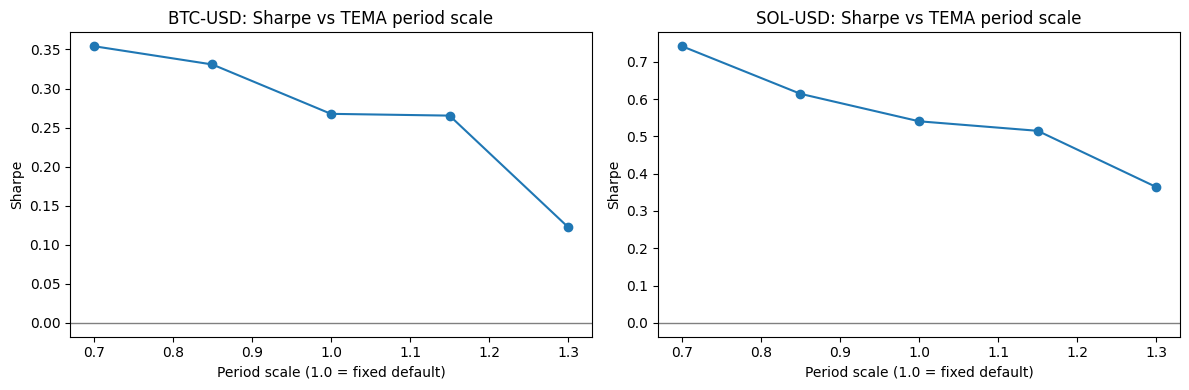

In [7]:
def stability_sweep(close, scale_grid=(0.7, 0.85, 1.0, 1.15, 1.3)):
    rows = []
    for scale in scale_grid:
        periods = tuple(max(2, int(p * scale)) for p in TEMA_PERIODS)
        state, _, _ = ensemble_state(close, tema_periods=periods)
        pos = vol_target_size(close, state)
        bt = backtest(close, pos)
        rows.append({"tema_period_scale": scale, "sharpe": annualized_sharpe(bt["ret"]),
                      "max_dd": max_drawdown(bt["equity"])})
    return pd.DataFrame(rows)


fig, axes = plt.subplots(1, len(TICKERS), figsize=(6 * len(TICKERS), 4))
if len(TICKERS) == 1:
    axes = [axes]
for ax, tkr in zip(axes, TICKERS):
    close = panel[tkr].dropna()
    stab = stability_sweep(close)
    print(f"--- {tkr} stability sweep ---")
    print(stab)
    ax.plot(stab["tema_period_scale"], stab["sharpe"], marker="o")
    ax.axhline(0, color="gray", lw=1)
    ax.set_title(f"{tkr}: Sharpe vs TEMA period scale")
    ax.set_xlabel("Period scale (1.0 = fixed default)"); ax.set_ylabel("Sharpe")
plt.tight_layout(); plt.show()


## 7 — Honest limitations

**"Boundless exit" is a real trade-off, not a free lunch.** The source material's argument —
trailing moving averages don't exit prematurely on a volatility spike — is legitimate. The flip
side, stated plainly: there is **no per-trade downside protection**. If price moves hard against
the position before the EMAs and MACD catch up and flip, this system holds through the entire
move. A fixed stop-loss would cap that single-trade loss at a known amount; this system
explicitly does not. That's the actual mechanism behind "boundless" — it isn't just terminology.

**If this is going into a prop account:** the drawdown governor built in the main notebook
(Section 8/9d — daily VaR cap, trailing drawdown throttle, cooldown/ramp) is a separate,
complementary layer that would sit on top of this ensemble's binary position rather than
replacing it. The ensemble decides direction and boundless timing; the governor decides how
much capital that direction is allowed to risk. Running the ensemble without a governor on a
funded account means the "no fixed exit" design decision is also, functionally, "no maximum
loss per trade" — worth being explicit about before sizing this with real capital.

**Still synthetic data.** Same caveat as the main notebook — see its Section 1 markdown for the
network restriction and exactly how to run this with real yfinance data (Colab, local Jupyter,
or Claude Code with real network access).

**Two names is not a lot of evidence.** BTC and SOL here are two individual backtests, not a
cross-sectional test — there's no claim here that this ensemble generalizes beyond these two
assets, only that it's internally consistent on each.